### This notebook compute "VSS5. Index of women's participation in agricultural activity " indicator for the 27 basins of IKI Project

Spanish: Índice de la participación de las  en la actividad agropecuaria

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite database.
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, reporte de INEI de Censos 2012

**Outputs:** 
 
**Assumptions:** Assigning index based on majority district. 
 
**Future work:** Normalize. Look into NA vs 0 handling. Look into using proportional method for these indices.
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 405 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [ ]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in excel  (save xls as xlsx as needed before reading in)
productores= pd.read_excel(f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/INEI_reporte_VSS5.xlsx')

top_row_name= 'Unnamed: 0'

In [ ]:
#FORMATTING THE DF

#remove empty rows 
productores = productores.dropna(axis=0, how='all')  # Drop rows that are completely NaN
#remove unnamed: 2 and and unnamed: 3 columns
productores = productores.drop(columns=[ 'Unnamed: 3'], errors='ignore')
#Keep only rows with 'Total' or 'AREA' in 'Temas de la capacitación' column
productores = productores[productores[top_row_name].str.contains('Total|AREA', case=False, na=False)]

#extract the district name from the dataframe and make a new column with just the district name
productores['District']= productores['Unnamed: 1'].str.split('Dist. ', expand=True)[1].str.strip()

indices_to_drop = []
# Iterate through the rows to check for AREA rows and their corresponding Total rows
for i in range(len(productores) - 1):  # Stop at the second-to-last row to avoid index errors
    if 'AREA' in str(productores.iloc[i][top_row_name]).upper():  # Check if the current row is an AREA row
        next_row = productores.iloc[i + 1]
        if 'TOTAL' in str(next_row[top_row_name]).upper():  # Check if the next row is a Total row
            # Assign the value from the next row to the "Total_Dist" column of the current row
            productores.at[productores.index[i], 'Total_Dist'] = next_row['Unnamed: 1']
            # Assign the value from the next row to the "Mujeres_Dist" column of the current row
            productores.at[productores.index[i], 'Mujeres_Dist'] = next_row['Unnamed: 2']
            # Mark the Total row for dropping
            indices_to_drop.append(productores.index[i + 1])


# Drop all marked indices at once
productores.drop(index=indices_to_drop, inplace=True)

# Reset the index after dropping rows
productores.reset_index(drop=True, inplace=True)

# Convert Total_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
productores['Total_Dist'] = pd.to_numeric(productores['Total_Dist'], errors='coerce').fillna(0)

# Convert Mujeres_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
productores['Mujeres_Dist'] = pd.to_numeric(productores['Mujeres_Dist'], errors='coerce').fillna(0)

#remove all rows from Temas that are NA
productores = productores.dropna(subset=[top_row_name])
#remove all rows from district that are NA
productores = productores.dropna(subset=['District'])

#Create column for District_ID by extracting the number after the # sign in the column Temas de la capacitación
productores['District_ID'] = productores[top_row_name].str.extract(r'(\d+)').astype(int) 

# Convert both columns to strings to be able to join them together
subbasins_gdf['IDDIST'] = subbasins_gdf['IDDIST'].astype(str)
productores['District_ID'] = productores['District_ID'].astype(str)

In [ ]:
#CALCULATION AND SCORE

#divide Mujeres_Dist by Total_Dist to get percentage of women
productores['VSS5'] = productores['Mujeres_Dist'] / productores['Total_Dist'] * 100

#Score according to percentage: 
#less than or equal to 10% = 0
#between 10 and 20 inclusive= .25
#between 20 and 25  inclusive= .5
#between 25 and 29 inclusive= .75
#greater than or equal to 30% = 1
def score_percentage(percentage):
    if percentage <= 10:
        return 0
    elif 10 < percentage <= 20:
        return 0.25
    elif 20 < percentage <= 25:
        return 0.5
    elif 25 < percentage <= 29:
        return 0.75
    elif percentage >= 30:
        return 1
    else:
        return np.nan  # Handle unexpected cases
productores['VSS5_Score'] = productores['VSS5'].apply(score_percentage)

#merge VSS5 column back to subbasins_gdf based on IDDIST and District_ID
subbasins_gdf = subbasins_gdf.merge(productores[['District_ID', 'VSS5_Score']], left_on='IDDIST', right_on='District_ID', how='left')

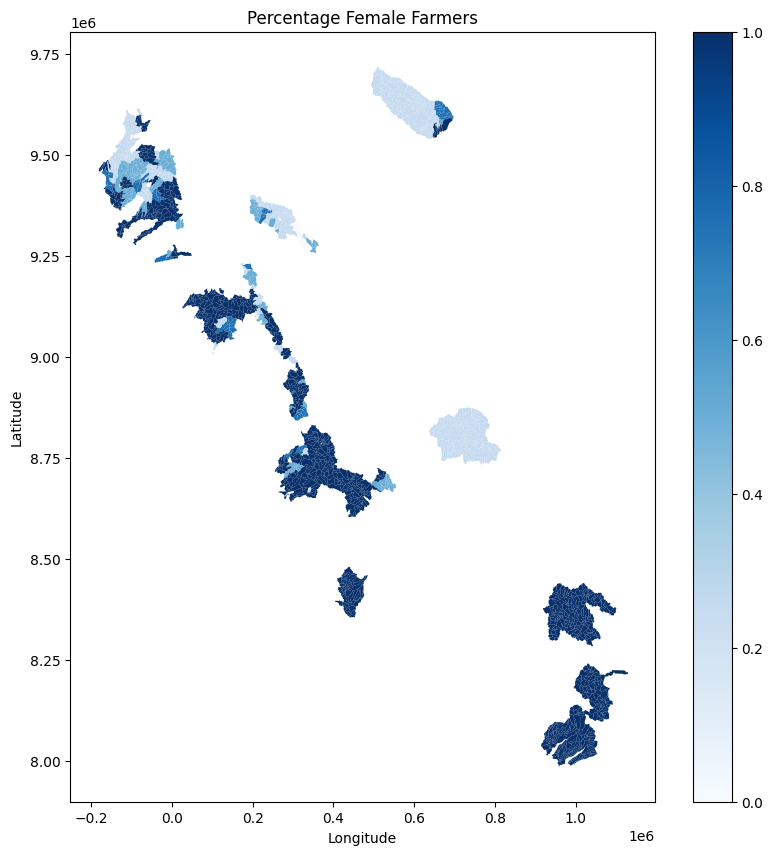

In [ ]:
#PLOT THE RESULTS

subbasins_gdf.plot(column='VSS5_Score', cmap='Blues', legend=True, figsize=(10, 10))
plt.title('Percentage Female Farmers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

SQLITE INSERT 

In [24]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and VSS5_Score
value_column= 'VSS5_Score' #Column with the calculated indicator values

In [25]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [29]:
rows_to_insert

[(1, 405, 311153600, 1.0),
 (1, 405, 310832400, 1.0),
 (1, 405, 310825700, nan),
 (1, 405, 310282400, 1.0),
 (1, 405, 308754600, 1.0),
 (1, 405, 307736500, nan),
 (1, 405, 307078200, 1.0),
 (1, 405, 307183500, 1.0),
 (1, 405, 306538400, 0.75),
 (1, 405, 306599700, 0.75),
 (1, 405, 306319300, 1.0),
 (1, 405, 306030000, 1.0),
 (1, 405, 305746400, 0.25),
 (1, 405, 311953100, 1.0),
 (1, 405, 304273900, 0.25),
 (1, 405, 304281100, 0.25),
 (1, 405, 304281200, 0.25),
 (1, 405, 304379300, 0.25),
 (1, 405, 304274000, 0.25),
 (1, 405, 304313700, 0.25),
 (1, 405, 304306400, 0.25),
 (1, 405, 304327700, 0.25),
 (1, 405, 304313800, 0.25),
 (1, 405, 304306300, 0.25),
 (1, 405, 304321600, 0.25),
 (1, 405, 304321700, 0.25),
 (1, 405, 304339400, 0.25),
 (1, 405, 304335700, 0.25),
 (1, 405, 304343200, 0.25),
 (1, 405, 304343100, 0.25),
 (1, 405, 304335800, 0.25),
 (1, 405, 304343000, 0.25),
 (1, 405, 304330900, 0.25),
 (1, 405, 304352700, 0.25),
 (1, 405, 304421200, 0.25),
 (1, 405, 304403000, 0.25),
 (1

In [26]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [27]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()